# Fiber Segmentation Tutorial with SAM2

This tutorial demonstrates the segmentation and structural analysis of fiber cross-section micrographs using SAM2 — the Segment Anything Model v2 developed by Meta (Facebook) Research.
SAM2 leverages Vision Transformers (ViT) to achieve highly flexible, prompt-based instance segmentation.

The workflow begins with the Automatic Mask Generator, which segments individual fiber cross sections in a single micrograph.
Subsequently, the notebook introduces a path extraction routine that subdivides large panoramic images into smaller, overlapping patches for detailed and systematic analysis.

This step-by-step guide provides a practical introduction to automated fiber segmentation and quantitative microstructural characterization.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/colab_analysis.ipynb)

## Environment Set-up
If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [1]:
using_colab = True

### Load Packages

In [6]:
if using_colab:
    import os
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    # Install the custom repo from the dev branch
    !{sys.executable} -m pip install 'git+https://github.com/choROPeNt/segment-anything-2.git@dev'
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops, label
    import pandas as pd
    from tqdm.auto import tqdm
    !mkdir -p ./images/
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/test.tiff
    !mkdir -p ./checkpoints/
    !wget -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
else:
    import os
    # if using Apple MPS, fall back to CPU for unsupported ops
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # quite nice life hack
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops_table, regionprops
    import pandas as pd
    from tqdm.auto import tqdm

PyTorch version: 2.8.0+cu126
Torchvision version: 0.23.0+cu126
CUDA is available: True
  Cloning https://github.com/choROPeNt/segment-anything-2.git (to revision dev) to /tmp/pip-req-build-tfmvpfvb
  Running command git clone --filter=blob:none --quiet https://github.com/choROPeNt/segment-anything-2.git /tmp/pip-req-build-tfmvpfvb
  Running command git checkout -b dev --track origin/dev
  Switched to a new branch 'dev'
  Branch 'dev' set up to track remote branch 'dev' from 'origin'.
  Resolved https://github.com/choROPeNt/segment-anything-2.git to commit 2819ea5de62570f54a7551359287ab68f4bd08ee
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--2025-10-23 12:23:21--  https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/test.tiff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercon

## Device Selection

PyTorch currently supports the following hardware acceleration backends and are recommended:

- **CUDA** — NVIDIA GPU acceleration (Linux and Windows)
- **MPS** — Metal Performance Shaders for Apple Silicon (macOS)
- **ROCm** — AMD GPU acceleration (Linux)

Other backends such as **XPU** (Intel) or **TPU** (Google Cloud) require separate extensions and are not part of the core PyTorch package.

| Backend    | Platform    |  PyTorch support   |  Notes   |
| --- | --- | --- | --- |
| `CUDA `   |  Linux / Windows   |  ✅ Fully supported   |  Standard GPU backend for NVIDIA cards.   |   
| `MPS`    |   macOS (Apple Silicon or AMD GPUs)  |  ✅ Supported (since 1.12)   |  Uses Apple Metal; some ops may still fall back to CPU. Some numerical differences to `CUDA`  |     
|  `ROCm`   |   Linux (AMD GPUs)  |  ✅ Supported (since 1.10, stable ≥ 1.12)   |  Official ROCm builds available from PyTorch.org.   |     
|   `XPU / SYCL`  |  Intel GPUs   |  🧪 Experimental   |  Via Intel Extension for PyTorch (not in core).   |    
|  `TPU`   |  Cloud (Google Colab `TPU` VMs)   |  ❌ Not in core PyTorch   |   Requires torch_xla separately.  |    





























In [8]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "\ngive numerically different outputs and sometimes degraded performance on MPS. "
        "\nSee e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


# Part 1: Single Image Analysis

## Load Image

**Note**: If your image is grayscale, you have to convert it to rgb to match SAM2 input size of `[x,y,3]`. The maximum image sizes is `1024**2`

In [12]:
file_path = "./images/test.tiff"

image = Image.open(file_path)

if image.mode in ("L", "I"):  # grayscale
    image = image.convert("RGB")
elif image.mode == "RGBA":    # drop alpha
    image = image.convert("RGB")

image_np = np.array(image)
print(f"Image has the shape {image_np.shape} and datatype {image_np.dtype}")

Image has the shape (728, 1630, 3) and datatype uint8


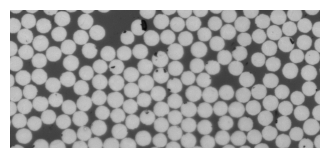

In [14]:
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

**Optional**: Center crop the image to match the input size

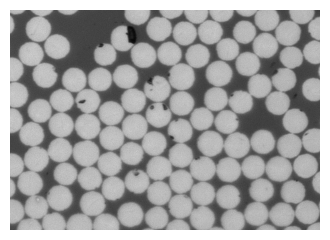

In [16]:
## center crop the image
def center_crop_np(image: np.ndarray, crop_size=1024):
    """Fast center crop for a NumPy image.

    Args:
        image (np.ndarray): Input image as a NumPy array (H, W) or (H, W, C).
        crop_size (int): Target crop size (assumes square crop).

    Returns:
        np.ndarray: Center-cropped image.
    """
    h, w = image.shape[:2]  # Get height and width
    ch, cw = crop_size, crop_size  # Crop size

    # Compute center crop coordinates
    start_h = max((h - ch) // 2, 0)
    start_w = max((w - cw) // 2, 0)
    end_h = min(start_h + ch, h)
    end_w = min(start_w + cw, w)

    return image[start_h:end_h, start_w:end_w]


image_np = center_crop_np(image_np)
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

## Automatic mask generation
To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [28]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

sam2_checkpoint = "./checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
        model=sam2,
        points_per_side=48,
        # points_per_batch=96,
        pred_iou_thresh=0.1,
        min_mask_region_area=50,
        box_nms_thresh=0.1,
        stability_score_thresh=0.95,  # Reduce the stability threshold to keep more masks
            )

To generate masks, simply call the generate function on an input image.

The resulting variable, masks, is a sequence of dictionaries, where each dictionary represents one detected region (fiber cross-section) and contains the following entries:
- segmentation : binary mask of the segmented region
- `area` : pixel area of the mask
- `bbox` : bounding box coordinates in the format `[x, y, width, height]`
- `predicted_iou` : model’s confidence estimate of segmentation accuracy (Intersection-over-Union (Jaccard) score)
- `point_coords` : coordinates of the prompt points used (if any)
- `stability_score` : measure of segmentation consistency under perturbations
- `crop_box` : image region from which the mask was generated

This output provides both the segmentation itself and useful metadata for filtering, analysis, or visualization.

In [29]:
print(f"Detection started...")
masks = mask_generator.generate(image_np)
print(f"Detection finished...")
print(f"Detected objects: {len(masks)}")

Detection started...
Detection finished...
Detected objects: 114


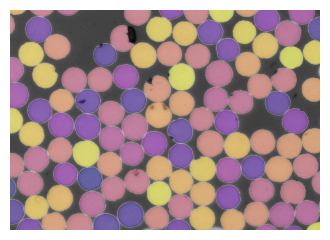

In [39]:
# Display some results
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
label_canvas = show_anns(masks)
plt.axis('off')
plt.show()

## Statistics

Using the `label_map`, we can now extract quantitative information about the segmented fiber cross sections.
For this purpose, we apply the function `regionprops` (`regionprops_table` returns a pandas dataframe) from the `scikit-image` package, which computes a wide range of morphological and intensity-based statistics for each labeled region (comparable to 1D-descriptors).

Typical properties include:
- Area: number of pixels belonging to each fiber
- Centroid: spatial position of the fiber center
- Equivalent diameter: diameter of a circle with the same area as the fiber
- Eccentricity: measure of how elongated the fiber cross section is
- Orientation: local rotation of the fitted ellipse

These descriptors enable detailed quantitative analysis of fiber size, shape, and spatial distribution within the micrograph.

In [40]:
def masks_to_labelmap(masks, image_shape):
    """
    Convert a list of SAM2 mask dictionaries to a label map.

    Parameters
    ----------
    masks : list of dict
        Each dictionary must contain a boolean array under the key 'segmentation'.
    image_shape : tuple
        Shape of the target label map (height, width).

    Returns
    -------
    label_map : np.ndarray, dtype=int16
        Label map where each segmented region is assigned a unique integer ID.
    """
    label_map = np.zeros(image_shape, dtype=np.int16)

    for i, mask_dict in enumerate(masks, start=1):
        mask = mask_dict["segmentation"]
        label_map[mask] = i

    return label_map

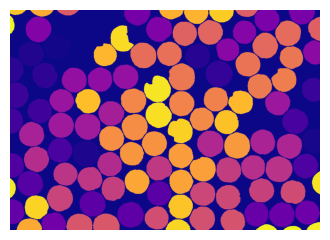

In [47]:
image_shape = image_np.shape[:2]

label_map = masks_to_labelmap(masks,image_shape)

# Display some results
plt.figure(figsize=(4, 4))
plt.imshow(label_map,cmap="plasma")
plt.axis('off')
plt.show()

In [48]:
# Compute region properties from the label map
result_dict = regionprops_table(
    label_map,
    properties=(
        "label",
        "area",
        "bbox",
        "centroid",
        "convex_area",
        "eccentricity",
        "equivalent_diameter",
        "extent",
        "feret_diameter_max",
        "filled_area",
        "major_axis_length",
        "minor_axis_length",
        "orientation",
        "perimeter",
        "solidity",
        "moments_hu",
    ),
)

# Convert to DataFrame for easier analysis
props_df = pd.DataFrame(result_dict)

# Display summary
print(f"Extracted {len(props_df)} fiber regions.")
props_df.head()



Extracted 114 fiber regions.


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,convex_area,eccentricity,...,orientation,perimeter,solidity,moments_hu-0,moments_hu-1,moments_hu-2,moments_hu-3,moments_hu-4,moments_hu-5,moments_hu-6
0,1,5583.0,83,112,167,199,124.286763,155.228372,5668.0,0.315004,...,1.370494,278.835570,0.985004,0.159431,0.000069,9.105405e-07,3.799760e-10,7.030686e-18,3.058808e-12,-7.232966e-19
1,2,4110.0,393,965,476,1024,433.675912,997.096837,4165.0,0.685240,...,0.007979,248.953319,0.986795,0.171802,0.002778,3.469536e-04,1.176367e-05,-7.515160e-10,-6.185103e-07,5.460805e-12
2,3,6031.0,433,208,520,296,475.238269,251.032830,6130.0,0.207026,...,-1.415349,289.421356,0.983850,0.159358,0.000012,7.692714e-06,3.225836e-09,-1.099938e-16,-1.065580e-11,4.961160e-16
3,4,5241.0,109,28,189,113,148.215417,69.228392,5332.0,0.297276,...,1.303901,270.592929,0.982933,0.159387,0.000054,1.113411e-06,7.368083e-10,-4.168276e-18,-3.365982e-12,-2.068800e-17
4,5,5091.0,115,579,195,661,154.617168,619.681399,5181.0,0.234492,...,-1.129983,266.693434,0.982629,0.159315,0.000020,8.384504e-07,2.593484e-10,-2.230321e-18,-4.134923e-13,-3.106728e-18


In [45]:
props_df.to_csv("results.csv",index=False)

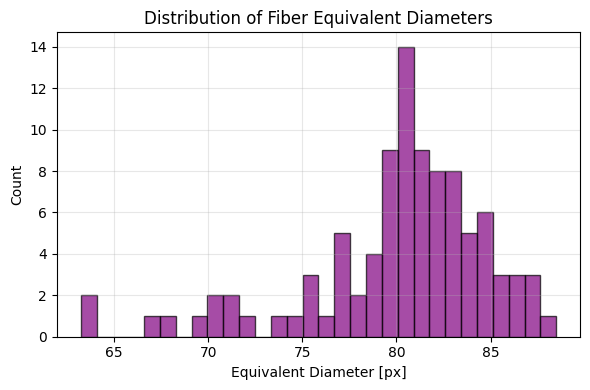

In [54]:
# Extract equivalent diameters from the DataFrame
equiv_diameters = props_df["equivalent_diameter"][props_df["area"] > 3000]

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(equiv_diameters, bins=30, facecolor="purple",edgecolor="black", alpha=0.7)

plt.title("Distribution of Fiber Equivalent Diameters")
plt.xlabel("Equivalent Diameter [px]")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Patch Analysis

In this section, we use the same input micrograph but subdivide it into multiple overlapping patches of size 1024 × 1024 pixels.
This patch-based approach enables efficient processing of large images that exceed GPU memory limits and allows for localized analysis of fiber size, shape, and distribution across different regions of the microstructure.

In [55]:
file_path = "./images/test.tiff"

image = Image.open(file_path)

if image.mode in ("L", "I"):  # grayscale
    image = image.convert("RGB")
elif image.mode == "RGBA":    # drop alpha
    image = image.convert("RGB")

image_np = np.array(image)
print(f"Image has the shape {image_np.shape} and datatype {image_np.dtype}")

Image has the shape (728, 1630, 3) and datatype uint8


In [79]:
from sam2.addons import Sam2Patcher

 ## intialize tiler
patcher = Sam2Patcher(
    patch_h=1024,
    patch_w=1024,
    overlap_h=512,
    overlap_w=512,
    pad_mode="constant",
    merge_iou=0.1
)

In [80]:
## Patching
patches, offsets, padded_shape = patcher.tile_numpy(image_np)
print(f"Tiled into {len(patches)} patches of shape {patches[0].shape}, \
      padded shape: {padded_shape}")

Tiled into 3 patches of shape (728, 1024, 3),       padded shape: (728, 1630, 3)


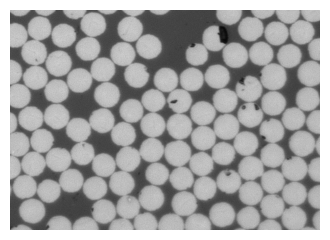

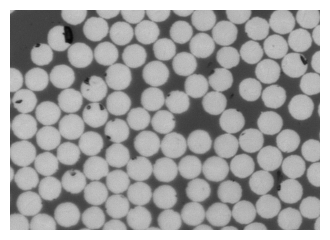

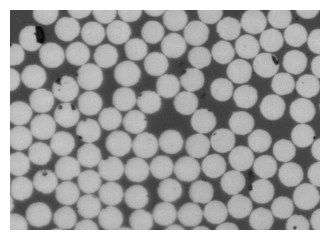

In [81]:
for i in range(min(4,len(patches))):
  plt.figure(figsize=(4,4))
  plt.imshow(patches[i])
  plt.axis("off")
  plt.show()

Loop over all patches and generate segmentation masks for the detected objects.
All results are collected into a sequence of lists of dictionaries, where each dictionary contains the segmentation data and associated metadata for one object.

In [82]:
#----- Mask Generation -----
all_detections = []
for p in tqdm(patches,
    total=len(patches),
    desc="Mask generation",
    unit="patch"
):
    ## detect masks per patch
    detections = mask_generator.generate(p)
    ## gather results
    all_detections.append(detections)

Mask generation:   0%|          | 0/3 [00:00<?, ?patch/s]

display some results

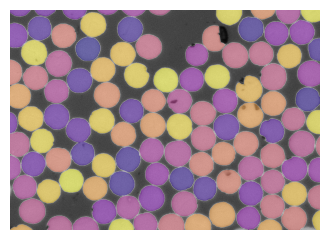

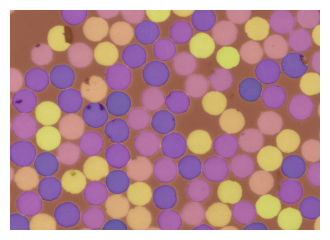

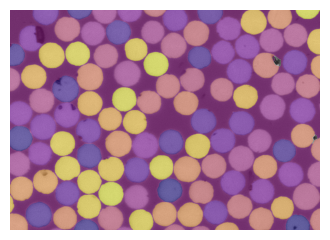

In [83]:
for i in range(min(4,len(patches))):
  plt.figure(figsize=(4,4))
  plt.imshow(patches[i])
  show_anns(all_detections[i])
  plt.axis("off")
  plt.show()

## Stitching the Results

After processing all patches, the individual results are gathered and stitched back together to reconstruct the segmentation of the original image.

**Note**:
Each entry in the resulting instances list is a dictionary containing the following fields:
- `"id"` — integer identifier corresponding to the label value in the `label_map`
- `"area"` — pixel area of the segmented region
- `"segmentation_crop"` — cropped segmentation mask (restricted to the bounding box to reduce data size)
- `"bbox"` — bounding box of the segmentation in the format `[x0, y0, w, h]`

In [84]:
label_map, instances = patcher.stitch_sam2_instances(
    padded_shape_hw=padded_shape[:2],
    offsets=offsets,
    per_tile_sam2=all_detections,
    debug=False,
)

In [85]:
# Optional: filter the instances by area and delete the biggest "background"
instances_sorted = sorted(instances, key=lambda x: x["area"])


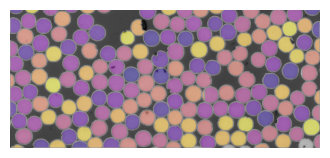

In [86]:
  plt.figure(figsize=(4,4))
  plt.imshow(image_np)
  show_anns(instances_sorted[:-1])
  plt.axis("off")
  plt.show()

## Save the Results
You can save the results from the `label_map` as `*.tiff` iamge e.g. to load it in Fiji as a labelmap. Refining the labels is managable via Labelkit.manageable via Labelkit.

In [78]:
Image.fromarray(label_map).save("results.tiff")

for very large files and panoramas it is recommended to safe the results as a `*.hdf5` container.

In [ ]:
dict_out = {
    "image": image ,
    "labels": label_map,
    "instances": instances
}

write_h5(path = "results.h5", dict_out= dict_out)